### !!! ROAD DAMAGE CLASSIFICATION USING DEEP LEARNING !!!

##### 1-IMPORT REQUIRED LIBRARIES

In [2]:
import os, random, shutil                     # File handling (folders, copying, shuffling)
import numpy as np                            # Numerical operations
import tensorflow as tf                       # Deep learning framework
import matplotlib.pyplot as plt               # Plotting graphs
import seaborn as sns                         # Advanced visualization

from PIL import Image                         # Image processing
from tensorflow.keras import layers, models   # Model building
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0  # Pretrained models
from tensorflow.keras.preprocessing.image import ImageDataGenerator              # Data loading + augmentation
from tensorflow.keras.callbacks import EarlyStopping                             # Stop training early
from sklearn.metrics import classification_report, confusion_matrix              # Evaluation metrics
from sklearn.utils.class_weight import compute_class_weight                      # Handle class imbalance


##### 2-PARAMETERS

In [3]:
IMG_SIZE = (224,224)                         # Input image size for models
BATCH_SIZE = 32                              # Number of images per batch

DATA_DIR = r"C:\Users\KAVIYA V\Downloads\Road Damage Dataset\data"  # Dataset root path
IMAGES_DIR = os.path.join(DATA_DIR, "images")                        # Images folder
LABELS_DIR = os.path.join(DATA_DIR, "labels")                        # Labels folder
OUTPUT_DIR = r"C:\Users\KAVIYA V\Downloads\processed_dataset_output"        # Processed dataset output

CLASS_MAP = {0:"Pothole",1:"Crack",2:"Manhole"}  # Class labels mapping

##### 3-CREATE DIRECTORIES

In [4]:
# Create folder structure for train/validation/test splits
for split in ["train","validation","test"]:
    for cls in CLASS_MAP.values():
        os.makedirs(os.path.join(OUTPUT_DIR,split,cls),exist_ok=True)

##### 4-FIX MULTI-LABEL

In [5]:
def get_primary_class(label_path):
    """
    Extract only the FIRST class from label file
    (avoids multi-label problem)
    """
    if not os.path.exists(label_path):
        return None                           # Return None if label file missing
    
    with open(label_path) as f:
        line = f.readline().split()           # Read first line
        return CLASS_MAP.get(int(line[0])) if line else None

##### 5-SPLIT DATASET

In [6]:
# Get all image filenames
images = [f for f in os.listdir(IMAGES_DIR) if f.endswith(('.jpg','.png'))]

random.shuffle(images)                        # Shuffle for randomness

# Define split ratios
train_split = int(0.7*len(images))            # 70% training
val_split = int(0.85*len(images))             # 15% validation

# Split dataset
train_imgs = images[:train_split]
val_imgs = images[train_split:val_split]
test_imgs = images[val_split:]

##### 6-ORGANIZE DATA

In [7]:
def process(images,split):
    """
    Copy images into respective class folders
    """
    for img in images:
        label_file = os.path.splitext(img)[0] + ".txt"  # Corresponding label file
        
        label = get_primary_class(os.path.join(LABELS_DIR,label_file))  # Get class
        
        if label:
            shutil.copy2(
                os.path.join(IMAGES_DIR,img),             # Source path
                os.path.join(OUTPUT_DIR,split,label,img)  # Destination path
            )

# Apply for all splits
process(train_imgs,"train")
process(val_imgs,"validation")
process(test_imgs,"test")

##### 7-DATA GENERATORS

In [8]:
# Training data augmentation
train_gen = ImageDataGenerator(
    rescale=1./255,                        # Normalize pixel values
    rotation_range=25,                     # Rotate images
    zoom_range=0.2,                        # Zoom augmentation
    horizontal_flip=True                   # Flip images
)

# Validation/Test (only normalization)
val_gen = ImageDataGenerator(rescale=1./255)

# Load datasets
train_ds = train_gen.flow_from_directory(
    os.path.join(OUTPUT_DIR,"train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = val_gen.flow_from_directory(
    os.path.join(OUTPUT_DIR,"validation"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = val_gen.flow_from_directory(
    os.path.join(OUTPUT_DIR,"test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False                           # Important for evaluation
)

Found 1406 images belonging to 3 classes.
Found 301 images belonging to 3 classes.
Found 302 images belonging to 3 classes.


##### 7.1-CLASS WEIGHTS (HANDLE IMBALANCE)

In [9]:
# Compute class weights to balance dataset
class_weights = compute_class_weight(
    "balanced",
    classes=np.unique(train_ds.classes),
    y=train_ds.classes
)

class_weights = dict(enumerate(class_weights))  # Convert to dictionary

##### 8-BASELINE CNN MODEL

In [10]:
baseline_model = models.Sequential([
    layers.Input(shape=(224,224,3)),       # Input layer

    layers.Conv2D(32,3,activation='relu'), # First conv layer
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'), # Second conv layer
    layers.MaxPooling2D(),

    layers.Flatten(),                      # Flatten feature maps

    layers.Dense(128,activation='relu'),   # Fully connected layer
    layers.Dense(3,activation='softmax')   # Output layer
])

# Compile model
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.4111 - loss: 1.7682 - val_accuracy: 0.3422 - val_loss: 1.1169
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 32s 737ms/step - accuracy: 0.3855 - loss: 1.0858 - val_accuracy: 0.3688 - val_loss: 1.0558
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 34s 763ms/step - accuracy: 0.4040 - loss: 1.0749 - val_accuracy: 0.3555 - val_loss: 1.0896
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 32s 731ms/step - accuracy: 0.4232 - loss: 1.0654 - val_accuracy: 0.3555 - val_loss: 1.1482
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 31s 707ms/step - accuracy: 0.4417 - loss: 1.0511 - val_accuracy: 0.4385 - val_loss: 1.0389


##### 9-MOBILENETV2 MODEL (TRANSFER LEARNING)

In [11]:
base = MobileNetV2(weights='imagenet',include_top=False,input_shape=(224,224,3))
base.trainable=False                        # Freeze base layers

mobilenet_model = models.Sequential([
    layers.Input(shape=(224,224,3)),

    layers.Rescaling(scale=2.0, offset=-1), # Normalize to [-1,1]

    base,                                   # Pretrained model

    layers.GlobalAveragePooling2D(),         # Reduce dimensions

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(3,activation='softmax')
])

mobilenet_model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

mobilenet_model.fit(train_ds,validation_data=val_ds,epochs=5,class_weight=class_weights)

# Fine-tuning last layers
for layer in base.layers[-20:]:
    layer.trainable=True

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.fit(train_ds,validation_data=val_ds,epochs=3)

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 774ms/step - accuracy: 0.4047 - loss: 1.1552 - val_accuracy: 0.5714 - val_loss: 0.9661
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 34s 762ms/step - accuracy: 0.4531 - loss: 1.0362 - val_accuracy: 0.5282 - val_loss: 0.9891
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 34s 778ms/step - accuracy: 0.4915 - loss: 1.0195 - val_accuracy: 0.5581 - val_loss: 0.9808
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 35s 792ms/step - accuracy: 0.5114 - loss: 0.9971 - val_accuracy: 0.5150 - val_loss: 0.9881
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 35s 790ms/step - accuracy: 0.4922 - loss: 0.9834 - val_accuracy: 0.6146 - val_loss: 0.9118
Epoch 1/3
44/44 ━━━━━━━━━━━━━━━━━━━━ 46s 918ms/step - accuracy: 0.5519 - loss: 0.9508 - val_accuracy: 0.6080 - val_loss: 0.9000
Epoch 2/3
44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 862ms/step - accuracy: 0.5462 - loss: 0.9508 - val_accuracy: 0.5914 - val_loss: 0.9046
Epoch 3/3
44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 846ms/step - accuracy: 0.5825 - loss: 0.9284 - val_accuracy: 0.

##### 10-RESNET50 MODEL

In [12]:
base = ResNet50(weights='imagenet',include_top=False,input_shape=(224,224,3))
base.trainable=False

resnet_model = models.Sequential([
    layers.Input(shape=(224,224,3)),

    layers.Rescaling(255.0),               # Scale for ResNet preprocessing
    layers.Lambda(tf.keras.applications.resnet50.preprocess_input),

    base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128,activation='relu'),
    layers.Dense(3,activation='softmax')
])

resnet_model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
resnet_model.fit(train_ds,validation_data=val_ds,epochs=5)


Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.4844 - loss: 1.1864 - val_accuracy: 0.5980 - val_loss: 0.9217
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.5768 - loss: 0.9223 - val_accuracy: 0.5847 - val_loss: 0.8784
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.5804 - loss: 0.9035 - val_accuracy: 0.5150 - val_loss: 0.9701
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.5868 - loss: 0.8962 - val_accuracy: 0.5814 - val_loss: 0.9167
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.5996 - loss: 0.8604 - val_accuracy: 0.6346 - val_loss: 0.8598


##### 11-EFFICIENTNET MODEL 

In [13]:
base = EfficientNetB0(weights='imagenet',include_top=False,input_shape=(224,224,3))
base.trainable=False

eff_model = models.Sequential([
    layers.Input(shape=(224,224,3)),

    layers.Rescaling(255.0),

    base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128,activation='relu'),
    layers.Dense(3,activation='softmax')
])

eff_model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
eff_model.fit(train_ds,validation_data=val_ds,epochs=5)

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 46s 873ms/step - accuracy: 0.5114 - loss: 1.0097 - val_accuracy: 0.6080 - val_loss: 0.9092
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 36s 810ms/step - accuracy: 0.5747 - loss: 0.9185 - val_accuracy: 0.6213 - val_loss: 0.8933
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 36s 824ms/step - accuracy: 0.6017 - loss: 0.8600 - val_accuracy: 0.6312 - val_loss: 0.8693
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 873ms/step - accuracy: 0.6373 - loss: 0.8163 - val_accuracy: 0.6246 - val_loss: 0.8486
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 927ms/step - accuracy: 0.6444 - loss: 0.7869 - val_accuracy: 0.5349 - val_loss: 0.9038


##### 12-MODEL EVALUATION

In [14]:
models_list = [
    (baseline_model,"CNN"),
    (mobilenet_model,"MobileNet"),
    (resnet_model,"ResNet"),
    (eff_model,"EffNet")
]

# Evaluate each model
for m,name in models_list:
    loss,acc = m.evaluate(test_ds)
    print(f"{name} Accuracy: {acc:.2f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 397ms/step - accuracy: 0.3974 - loss: 1.0565
CNN Accuracy: 0.40
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 401ms/step - accuracy: 0.5265 - loss: 0.9597
MobileNet Accuracy: 0.53
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5695 - loss: 0.9342
ResNet Accuracy: 0.57
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 515ms/step - accuracy: 0.5828 - loss: 0.8922
EffNet Accuracy: 0.58


##### 13-FINAL METRICS

10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 553ms/step
              precision    recall  f1-score   support

           0       0.59      0.75      0.66       143
           1       0.51      0.40      0.45        91
           2       0.31      0.24      0.27        68

    accuracy                           0.53       302
   macro avg       0.47      0.46      0.46       302
weighted avg       0.51      0.53      0.51       302



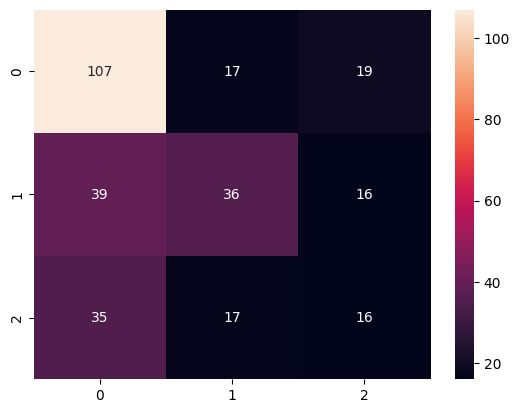

In [15]:
best_model = mobilenet_model               # Select best model

pred = best_model.predict(test_ds)         # Predict probabilities
y_pred = np.argmax(pred,axis=1)            # Convert to class labels

# Print classification report
print(classification_report(test_ds.classes,y_pred))

# Confusion matrix
cm = confusion_matrix(test_ds.classes,y_pred)

sns.heatmap(cm,annot=True,fmt='d')         # Plot heatmap
plt.show()

##### 14-SAVE MODEL

In [16]:
best_model.save("final_model_here.h5")     # Save trained model

print("MODEL SAVED SUCCESSFULLY")

✅ MODEL SAVED SUCCESSFULLY
